# Baseline clásico definitivo: siete dominios mixtos con Random Forest

Este notebook reproduce la filosofía de los experimentos CNN con un estimador clásico. La pregunta es si un modelo no neuronal puede clasificar minerales a partir de espectros Raman armonizados cuando validación y prueba contienen **fuentes RRUFF no vistas**.

El flujo es íntegramente reproducible y evita *data leakage*: lectura y auditoría → rejilla Raman común → normalización física por espectro → split global por `source_id` → grid search solo con entrenamiento/validación → reajuste del pipeline ganador → evaluación única sobre test → exportación del pipeline completo.

No debe compararse únicamente el mejor valor aislado: se deben contrastar Top-1/3/5, macro F1, weighted F1, calibración, rendimiento por dominio y coste computacional con los notebooks CNN.

Este notebook lee los TXT directamente desde los ZIP y muestra resultados inline. No exporta archivos ni crea carpetas de resultados.

## 1. Importaciones, versiones y reproducibilidad

Se fijan semillas y se registran versiones. El notebook no requiere TensorFlow ni GPU.

In [1]:
import os, re, json, random, zipfile, platform, time, hashlib, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from scipy.special import softmax
from sklearn import __version__ as sklearn_version
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import (
    log_loss, accuracy_score, top_k_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, average_precision_score,
)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("Python:", platform.python_version())
print("scikit-learn:", sklearn_version)
print("NumPy:", np.__version__)
print("✓ Reproducibilidad configurada")
# Modo solo pantalla: no se escriben resultados en disco.
def _mostrar_en_pantalla(obj, destino=None, *args, **kwargs):
    nombre = str(destino) if destino is not None else "salida tabular"
    print(f"\n[SOLO PANTALLA] {nombre} | dimensiones: {getattr(obj, 'shape', None)}")
    try:
        display(obj if len(obj) <= 40 else obj.head(40))
    except Exception:
        print(obj)

pd.DataFrame.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
pd.Series.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
np.save = lambda destino, datos, *a, **k: _mostrar_en_pantalla(pd.DataFrame(np.atleast_1d(datos)), destino)
plt.savefig = lambda destino, *a, **k: print(f"[SOLO PANTALLA] Figura mostrada; no se guarda {destino}")
Path.write_text = lambda self, data, *a, **k: print(f"[SOLO PANTALLA] {self.name}:\n{str(data)[:4000]}") or len(str(data))

class ZipMember:
    """Referencia ligera a un TXT dentro de un ZIP, sin extracción a disco."""
    def __init__(self, archive_path, member):
        self.archive_path, self.member = Path(archive_path), member
    @property
    def name(self): return Path(self.member).name
    def read_bytes(self):
        with zipfile.ZipFile(self.archive_path) as zf: return zf.read(self.member)
    def __str__(self): return f"{self.archive_path.name}::{self.member}"
    def __repr__(self): return str(self)

def open_spectrum(member):
    import io
    return io.StringIO(member.read_bytes().decode("utf-8", errors="replace"))


Python: 3.11.15
scikit-learn: 1.9.0
NumPy: 2.4.6
✓ Reproducibilidad configurada


## 2. Configuración del experimento

Se conservan los siete ZIP, la rejilla de 512 puntos y los criterios de inclusión del benchmark CNN mixto.

In [2]:
REQUIRED_ZIP_FILENAMES = [
    "excellent_unoriented.zip", "excellent_oriented.zip",
    "fair_unoriented.zip", "fair_oriented.zip",
    "poor_unoriented.zip", "unrated_unoriented.zip", "unrated_oriented.zip",
]
ARCHIVE_SEARCH_DIRS = [Path.cwd(), Path.cwd() / "upload", Path("/content")]

NOTEBOOK_VERSION = "ALL_7_ZIPS_RF_EXPANDED_GRID_SEARCH_2026_08_12"
MODEL_NAME = "Random Forest"
WORK_DIR = Path("raman_all_7_zips_random_forest_grid_search")
EXTRACT_ROOT = WORK_DIR / "extracted"
RESULTS_DIR = WORK_DIR / "results"
PRODUCTION_DIR = RESULTS_DIR / "production"

MIN_CLASS_COUNT = 5
MIN_SOURCE_GROUPS = 3
REQUIRE_RELIABLE_SOURCE_IDS = True
N_GRID_POINTS = 512
COVERAGE_FRACTION = 0.95
N_SPLIT_CANDIDATES = 1000
SCORING = "f1_macro"


config = {
    "notebook_version": NOTEBOOK_VERSION,
    "model": MODEL_NAME,
    "split_seed": SEED,
    "required_archives": REQUIRED_ZIP_FILENAMES,
    "evaluation_domain": "siete dominios RRUFF mixtos",
    "split_policy": "partición global por source_id; test queda fuera del grid search",
    "selection_metric": SCORING,
    "min_class_count": MIN_CLASS_COUNT,
    "min_source_groups": MIN_SOURCE_GROUPS,
    "n_grid_points": N_GRID_POINTS,
    "coverage_fraction": COVERAGE_FRACTION,
}
(RESULTS_DIR / "config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")
print(f"✓ Configuración guardada: {NOTEBOOK_VERSION}")


[SOLO PANTALLA] config.json:
{
  "notebook_version": "ALL_7_ZIPS_RF_EXPANDED_GRID_SEARCH_2026_08_12",
  "model": "Random Forest",
  "split_seed": 42,
  "required_archives": [
    "excellent_unoriented.zip",
    "excellent_oriented.zip",
    "fair_unoriented.zip",
    "fair_oriented.zip",
    "poor_unoriented.zip",
    "unrated_unoriented.zip",
    "unrated_oriented.zip"
  ],
  "evaluation_domain": "siete dominios RRUFF mixtos",
  "split_policy": "partici\u00f3n global por source_id; test queda fuera del grid search",
  "selection_metric": "f1_macro",
  "min_class_count": 5,
  "min_source_groups": 3,
  "n_grid_points": 512,
  "coverage_fraction": 0.95
}
✓ Configuración guardada: ALL_7_ZIPS_RF_EXPANDED_GRID_SEARCH_2026_08_12


## 3. Localización, integridad y extracción de los siete ZIP

Cada archivo debe existir y superar la prueba de integridad. Los duplicados exactos se eliminan por SHA-256 antes de cualquier partición.

In [3]:
def slug_from_archive(path):
    slug = re.sub(r"[^a-z0-9]+", "_", path.stem.lower()).strip("_")
    return slug or "archive"

def resolve_required_archives():
    resolved = {}
    duplicate_locations = {}
    for filename in REQUIRED_ZIP_FILENAMES:
        matches = [
            (folder / filename).resolve()
            for folder in ARCHIVE_SEARCH_DIRS
            if (folder / filename).is_file()
        ]
        if matches:
            resolved[filename] = matches[0]
            if len(matches) > 1:
                duplicate_locations[filename] = [str(path) for path in matches]
    missing = [name for name in REQUIRED_ZIP_FILENAMES if name not in resolved]
    if missing:
        raise FileNotFoundError(
            "Faltan los archivos Raman requeridos: " + ", ".join(missing) +
            ". Colóquelos junto al notebook, en upload/ o en /content."
        )
    if duplicate_locations:
        print("Nota: se encontraron ubicaciones duplicadas; se utiliza la primera coincidencia:")
        print(json.dumps(duplicate_locations, indent=2))
    return resolved

resolved_archives = resolve_required_archives()
archive_specs = [
    (slug_from_archive(Path(filename)), resolved_archives[filename])
    for filename in REQUIRED_ZIP_FILENAMES
]

archive_inventory = pd.DataFrame([
    {
        "dataset_subset": subset,
        "zip_filename": path.name,
        "zip_path": str(path),
        "role": "mixed_domain_train_validation_test",
    }
    for subset, path in archive_specs
])
archive_inventory.to_csv(RESULTS_DIR / "archive_inventory.csv", index=False)
display(archive_inventory)

file_entries = []
archive_file_counts = []
for dataset_subset, zip_path in archive_specs:
    with zipfile.ZipFile(zip_path) as archive:
        members = sorted(n for n in archive.namelist() if n.lower().endswith(".txt"))
    if not members:
        raise RuntimeError(f"{zip_path.name} no contiene espectros .txt.")
    subset_files = [ZipMember(zip_path, member) for member in members]
    file_entries.extend((path, dataset_subset) for path in subset_files)
    archive_file_counts.append({"dataset_subset": dataset_subset, "zip_filename": zip_path.name, "text_files": len(subset_files)})
    print(f"{dataset_subset}: {len(subset_files)} TXT leídos directamente de {zip_path.name}")

# Los duplicados exactos se detectan sobre los bytes internos, sin extraerlos.
seen_hashes, unique_entries, duplicate_rows = {}, [], []
for path, dataset_subset in file_entries:
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest in seen_hashes:
        kept_path, kept_subset = seen_hashes[digest]
        duplicate_rows.append({"excluded_filepath": str(path), "excluded_subset": dataset_subset,
                               "kept_filepath": str(kept_path), "kept_subset": kept_subset, "sha256": digest})
    else:
        seen_hashes[digest] = (path, dataset_subset)
        unique_entries.append((path, dataset_subset))

duplicate_table = pd.DataFrame(duplicate_rows)
display(duplicate_table.head(40))
filepaths = [path for path, _ in unique_entries]
dataset_by_path = {str(path): subset for path, subset in unique_entries}
print("Archivos TXT únicos:", len(filepaths))
print("Duplicados exactos excluidos:", len(duplicate_rows))
print("✓ ZIP leídos directamente; no se crearon carpetas de extracción")



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/archive_inventory.csv | dimensiones: (7, 4)


,dataset_subset,zip_filename,zip_path,role
0,excellent_unoriented,excellent_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,mixed_domain_train_validation_test
1,excellent_oriented,excellent_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,mixed_domain_train_validation_test
2,fair_unoriented,fair_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,mixed_domain_train_validation_test
3,fair_oriented,fair_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,mixed_domain_train_validation_test
4,poor_unoriented,poor_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/poor...,mixed_domain_train_validation_test
5,unrated_unoriented,unrated_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,mixed_domain_train_validation_test
6,unrated_oriented,unrated_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,mixed_domain_train_validation_test


,dataset_subset,zip_filename,zip_path,role
0,excellent_unoriented,excellent_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,mixed_domain_train_validation_test
1,excellent_oriented,excellent_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/exce...,mixed_domain_train_validation_test
2,fair_unoriented,fair_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,mixed_domain_train_validation_test
3,fair_oriented,fair_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/fair...,mixed_domain_train_validation_test
4,poor_unoriented,poor_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/poor...,mixed_domain_train_validation_test
5,unrated_unoriented,unrated_unoriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,mixed_domain_train_validation_test
6,unrated_oriented,unrated_oriented.zip,/Users/nico/anaconda_projects/TFM - FINAL/unra...,mixed_domain_train_validation_test


excellent_unoriented: 11415 TXT leídos directamente de excellent_unoriented.zip
excellent_oriented: 7668 TXT leídos directamente de excellent_oriented.zip
fair_unoriented: 2951 TXT leídos directamente de fair_unoriented.zip
fair_oriented: 25 TXT leídos directamente de fair_oriented.zip
poor_unoriented: 1639 TXT leídos directamente de poor_unoriented.zip
unrated_unoriented: 639 TXT leídos directamente de unrated_unoriented.zip
unrated_oriented: 3778 TXT leídos directamente de unrated_oriented.zip


,excluded_filepath,excluded_subset,kept_filepath,kept_subset,sha256
0,excellent_oriented.zip::Baddeleyite__R060016-3...,excellent_oriented,excellent_oriented.zip::Baddeleyite__R060016-3...,excellent_oriented,426f0f31f6c1625b1daf383871926cba440399f61d381d...
1,excellent_oriented.zip::Calcite__R050009-3__Ra...,excellent_oriented,excellent_oriented.zip::Calcite__R050009-3__Ra...,excellent_oriented,17ad51cea7b9a9d245ed9dbcba04adea065f7285ce1283...
2,excellent_oriented.zip::Dolomite__R050241-3__R...,excellent_oriented,excellent_oriented.zip::Dolomite__R050241-3__R...,excellent_oriented,8d37941f3aa0c961cdf13ccf4f66266b22fa7d42751dd2...
3,excellent_oriented.zip::Dolomite__R050241-3__R...,excellent_oriented,excellent_oriented.zip::Dolomite__R050241-3__R...,excellent_oriented,b8339091a2a81de275fea839312b7db4882a448e7f3472...
4,excellent_oriented.zip::Forsterite__R060539-5_...,excellent_oriented,excellent_oriented.zip::Forsterite__R060539-5_...,excellent_oriented,4c4e05dcfe04d5575657a7c5d7304d84c85c06feded390...
5,excellent_oriented.zip::Talc__R050087-5__Raman...,excellent_oriented,excellent_oriented.zip::Talc__R050087-5__Raman...,excellent_oriented,e173170cf8eafa3a1fba838c5e2fd095545bb7d765c876...
6,excellent_oriented.zip::Talc__R050087-6__Raman...,excellent_oriented,excellent_oriented.zip::Talc__R050087-6__Raman...,excellent_oriented,b1d488f58d23e1bd8e24044d9cfa1e04af9683c52b3aad...
7,excellent_oriented.zip::Talc__R050087-7__Raman...,excellent_oriented,excellent_oriented.zip::Talc__R050087-7__Raman...,excellent_oriented,6da97731c820f191d32c3b37255ff6d8b9fe2bd255aeae...
8,unrated_unoriented.zip::Margarosanite__R120111...,unrated_unoriented,excellent_unoriented.zip::Margarosanite__R1201...,excellent_unoriented,82cca24642ab104d957d1125f37c3ecddf6069ebecc118...
9,unrated_unoriented.zip::Margarosanite__R120111...,unrated_unoriented,excellent_unoriented.zip::Margarosanite__R1201...,excellent_unoriented,b43350d5cb50e8aecb10e32dee0153b5f00c5151b4b315...


Archivos TXT únicos: 28099
Duplicados exactos excluidos: 16
✓ ZIP leídos directamente; no se crearon carpetas de extracción


## 4. Lectura de espectros y auditoría de identificadores RRUFF

`source_id` representa la muestra física de procedencia. Si no puede resolverse sin ambigüedad, el espectro se pone en cuarentena.

In [4]:
NUMBER = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[Ee][-+]?\d+)?")
RRUFF_ID = re.compile(r"(?<![A-Za-z0-9])R\d{6,8}(?!\d)", re.IGNORECASE)

def mineral_from_filename(path):
    label = path.name.split("__")[0].strip()
    return label.replace("_", " ")

def unique_rruff_ids(text):
    return sorted({m.upper() for m in RRUFF_ID.findall(text)})

def load_spectrum_and_header(path):
    pairs, header_lines = [], []
    try:
        with open_spectrum(path) as handle:
            for line in handle:
                if line.lstrip().startswith("##"):
                    header_lines.append(line.strip())
                    continue
                if not line.strip():
                    continue
                values = NUMBER.findall(line)
                if len(values) >= 2:
                    try:
                        pairs.append((float(values[0]), float(values[1])))
                    except ValueError:
                        pass
        if len(pairs) < 10:
            return None, header_lines, "menos de 10 pares numéricos"
        arr = np.asarray(pairs, dtype=np.float64)
        arr = arr[np.isfinite(arr[:, 0])]
        if len(arr) < 10:
            return None, header_lines, "muy pocas coordenadas Raman finitas"
        if not np.isfinite(arr[:, 1]).all():
            return None, header_lines, "intensidades no finitas"
        frame = pd.DataFrame({"shift": arr[:, 0], "intensity": arr[:, 1]})
        frame = frame.groupby("shift", as_index=False)["intensity"].mean().sort_values("shift")
        if len(frame) < 10 or frame["shift"].iloc[-1] <= frame["shift"].iloc[0]:
            return None, header_lines, "eje Raman degenerado"
        if np.max(np.abs(frame["intensity"].to_numpy())) <= 1e-12:
            return None, header_lines, "espectro plano o prácticamente nulo"
        spectrum = (frame["shift"].to_numpy(), frame["intensity"].to_numpy())
        return spectrum, header_lines, None
    except Exception as exc:
        return None, header_lines, f"error de lectura: {type(exc).__name__}"

records, parsed = [], {}
for i, path in enumerate(filepaths):
    dataset_subset = dataset_by_path[str(path)]
    result, header_lines, reason = load_spectrum_and_header(path)
    filename_ids = unique_rruff_ids(path.name)
    header_ids = unique_rruff_ids("\n".join(header_lines))
    candidate_ids = sorted(set(filename_ids) | set(header_ids))
    conflict = bool(filename_ids and header_ids and set(filename_ids) != set(header_ids))
    resolved_source_id = candidate_ids[0] if len(candidate_ids) == 1 and not conflict else None
    if conflict:
        source_status = "filename_header_conflict"
    elif len(candidate_ids) == 0:
        source_status = "missing"
    elif len(candidate_ids) > 1:
        source_status = "multiple_candidates"
    elif filename_ids and header_ids:
        source_status = "filename_header_agree"
    elif filename_ids:
        source_status = "filename_only"
    else:
        source_status = "header_only"

    label = mineral_from_filename(path)
    record = {
        "spectrum_id": f"S{i:06d}", "filepath": str(path), "filename": path.name,
        "dataset_subset": dataset_subset, "label": label, "accepted_parse": result is not None, "rejection_reason": reason,
        "source_id_filename": "|".join(filename_ids),
        "source_id_header": "|".join(header_ids),
        "source_id": resolved_source_id,
        "source_id_status": source_status,
    }
    if result is not None:
        shift, intensity = result
        record.update(n_points=len(shift), min_shift=float(shift.min()), max_shift=float(shift.max()))
        parsed[record["spectrum_id"]] = (shift, intensity)
    records.append(record)

manifest = pd.DataFrame(records)
source_audit = manifest[[
    "spectrum_id", "filepath", "dataset_subset", "label", "source_id_filename", "source_id_header",
    "source_id", "source_id_status", "accepted_parse"
]].copy()
source_audit.to_csv(RESULTS_DIR / "source_id_audit.csv", index=False)
manifest.to_csv(RESULTS_DIR / "parsing_manifest.csv", index=False)

parse_by_archive = (manifest.groupby("dataset_subset", as_index=False)
                    .agg(unique_text_files=("spectrum_id", "size"),
                         parsed_spectra=("accepted_parse", "sum")))
parse_by_archive["parsed_spectra"] = parse_by_archive["parsed_spectra"].astype(int)
expected_subsets = set(archive_inventory["dataset_subset"])
observed_subsets = set(parse_by_archive["dataset_subset"])
if observed_subsets != expected_subsets:
    raise RuntimeError(f"Inconsistencia en el seguimiento de archivos. Faltan subconjuntos: {sorted(expected_subsets - observed_subsets)}")
zero_parsed = parse_by_archive.loc[parse_by_archive["parsed_spectra"] == 0, "dataset_subset"].tolist()
if zero_parsed:
    raise RuntimeError("Estos archivos requeridos no produjeron ningún espectro válido: " + ", ".join(zero_parsed))
parse_by_archive.to_csv(RESULTS_DIR / "parsed_spectra_by_archive.csv", index=False)
display(parse_by_archive)
print("Archivos leídos correctamente:", int(manifest["accepted_parse"].sum()))
print("Archivos rechazados durante la lectura:", int((~manifest["accepted_parse"]).sum()))
display(manifest["source_id_status"].value_counts(dropna=False).rename("count").to_frame())
display(manifest.loc[~manifest["accepted_parse"], "rejection_reason"].value_counts().rename("count").to_frame())
print("✓ Manifiesto de lectura y auditoría de identificadores de fuente guardados")



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/source_id_audit.csv | dimensiones: (28099, 9)


,spectrum_id,filepath,dataset_subset,label,source_id_filename,source_id_header,source_id,source_id_status,accepted_parse
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,excellent_unoriented,Abellaite,R250095,R250095,R250095,filename_header_agree,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,excellent_unoriented,Abellaite,R250095,R250095,R250095,filename_header_agree,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,excellent_unoriented,Abelsonite,R070007,R070007,R070007,filename_header_agree,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,excellent_unoriented,Abelsonite,R070007,R070007,R070007,filename_header_agree,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,excellent_unoriented,Actinolite,R040063,R040063,R040063,filename_header_agree,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,excellent_unoriented,Actinolite,R040063,R040063,R040063,filename_header_agree,True



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/parsing_manifest.csv | dimensiones: (28099, 14)


,spectrum_id,filepath,filename,dataset_subset,label,accepted_parse,rejection_reason,source_id_filename,source_id_header,source_id,source_id_status,n_points,min_shift,max_shift
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2312,153.55700,1267.727
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2379,153.55700,1300.029
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2367,163.43140,1304.119
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2515,92.07813,1304.119
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/parsed_spectra_by_archive.csv | dimensiones: (7, 3)


...

,dataset_subset,unique_text_files,parsed_spectra
0,excellent_oriented,7660,7660
1,excellent_unoriented,11415,11415
2,fair_oriented,25,25
3,fair_unoriented,2951,2951
4,poor_unoriented,1639,1639
5,unrated_oriented,3772,3772
6,unrated_unoriented,637,637


Archivos leídos correctamente: 28099
Archivos rechazados durante la lectura: 0


,count
source_id_status,
filename_header_agree,26188
filename_header_conflict,1605
missing,295
header_only,9
filename_only,2


,count
rejection_reason,


✓ Manifiesto de lectura y auditoría de identificadores de fuente guardados


## 5. Rejilla Raman común y control de cobertura

La rejilla se deriva del dominio de referencia `excellent_unoriented` y luego se aplica igual a los siete dominios.

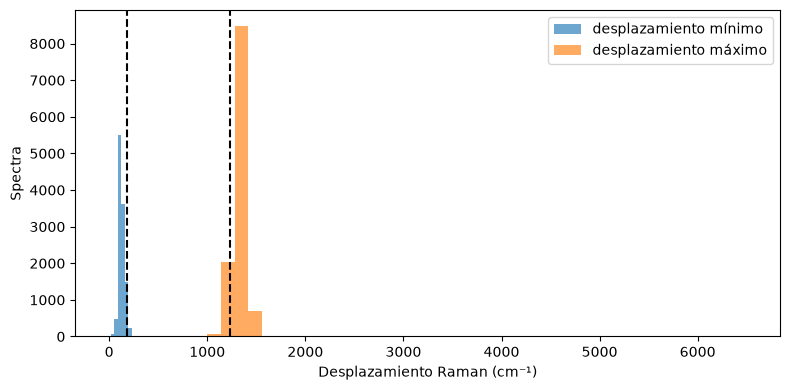

Intervalo seleccionado: 180.71–1236.15 cm⁻¹
Grid: 512 puntos; separación 2.065 cm⁻¹


,parsed,complete_coverage
dataset_subset,,
excellent_oriented,7660,6939
excellent_unoriented,11415,10299
fair_oriented,25,20
fair_unoriented,2951,2338
poor_unoriented,1639,1324
unrated_oriented,3772,3532
unrated_unoriented,637,567


Espectros con cobertura completa en el conjunto de siete dominios: 25019


In [5]:
ok = manifest[manifest["accepted_parse"]].copy()
ok_reference = ok[ok["dataset_subset"] == "excellent_unoriented"].copy()
if ok_reference.empty:
    raise RuntimeError("No se pudo leer correctamente ningún espectro excellent-unoriented.")
LOWER_LIMIT = float(np.quantile(ok_reference["min_shift"], COVERAGE_FRACTION))
UPPER_LIMIT = float(np.quantile(ok_reference["max_shift"], 1 - COVERAGE_FRACTION))
if LOWER_LIMIT >= UPPER_LIMIT:
    raise RuntimeError("No se encontró un intervalo Raman común válido. Revise el gráfico de cobertura y los archivos de datos.")
target_grid = np.linspace(LOWER_LIMIT, UPPER_LIMIT, N_GRID_POINTS, dtype=np.float32)

coverage_ok = (ok["min_shift"] <= LOWER_LIMIT) & (ok["max_shift"] >= UPPER_LIMIT)
coverage_ids = set(ok.loc[coverage_ok, "spectrum_id"])
manifest["accepted_coverage"] = manifest["spectrum_id"].isin(coverage_ids)
mask = manifest["accepted_parse"] & ~manifest["accepted_coverage"]
manifest.loc[mask, "rejection_reason"] = "cobertura insuficiente del intervalo común"

plt.figure(figsize=(8, 4))
plt.hist(ok_reference["min_shift"], bins=40, alpha=0.65, label="desplazamiento mínimo")
plt.hist(ok_reference["max_shift"], bins=40, alpha=0.65, label="desplazamiento máximo")
plt.axvline(LOWER_LIMIT, color="black", linestyle="--")
plt.axvline(UPPER_LIMIT, color="black", linestyle="--")
plt.xlabel("Desplazamiento Raman (cm⁻¹)"); plt.ylabel("Spectra"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Intervalo seleccionado: {LOWER_LIMIT:.2f}–{UPPER_LIMIT:.2f} cm⁻¹")
print(f"Grid: {N_GRID_POINTS} puntos; separación {target_grid[1]-target_grid[0]:.3f} cm⁻¹")
display(manifest[manifest["accepted_parse"]].groupby("dataset_subset")["accepted_coverage"].agg(parsed="size", complete_coverage="sum"))
print("Espectros con cobertura completa en el conjunto de siete dominios:", len(coverage_ids))


## 6. Interpolación, normalización y selección de clases

Cada espectro se interpola y se divide por su máxima intensidad absoluta. Esta normalización por muestra no aprende estadísticas globales y, por tanto, no transmite información entre particiones.

In [6]:
X_list, labels, metadata_rows = [], [], []
for row in manifest[manifest["accepted_coverage"]].itertuples():
    shift, intensity = parsed[row.spectrum_id]
    interpolated = np.interp(target_grid, shift, intensity).astype(np.float32)
    scale = float(np.max(np.abs(interpolated)))
    if not np.isfinite(scale) or scale <= 1e-12:
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "accepted_coverage"] = False
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "rejection_reason"] = "divisor de normalización no válido"
        continue
    normalized = (interpolated / scale).astype(np.float32)
    if not np.isfinite(normalized).all():
        raise AssertionError(f"Valores normalizados no finitos en {row.filepath}")
    X_list.append(normalized); labels.append(row.label)
    metadata_rows.append({
        "spectrum_id": row.spectrum_id, "filepath": row.filepath, "filename": row.filename,
        "dataset_subset": row.dataset_subset, "label": row.label, "source_id": row.source_id, "source_id_status": row.source_id_status,
    })

X_all = np.asarray(X_list, dtype=np.float32)
metadata_all = pd.DataFrame(metadata_rows)
missing_source = metadata_all["source_id"].isna()
n_unresolved = int(missing_source.sum())
if n_unresolved:
    unresolved = metadata_all.loc[missing_source, [
        "spectrum_id", "filepath", "filename", "dataset_subset", "label", "source_id_status"
    ]].copy()
    unresolved.to_csv(RESULTS_DIR / "excluded_unresolved_source_ids.csv", index=False)
    print(f"Se ponen en cuarentena {n_unresolved} espectros utilizables sin un identificador de fuente resuelto de manera inequívoca.")
    display(unresolved.head(30))

if REQUIRE_RELIABLE_SOURCE_IDS:
    resolved_mask = (~missing_source).to_numpy()
    X_all = X_all[resolved_mask]
    metadata_all = metadata_all.loc[~missing_source].reset_index(drop=True)

if len(metadata_all) == 0:
    raise RuntimeError(
        "No spectra with reliable source IDs remain. Review source_id_audit.csv and "
        "excluded_unresolved_source_ids.csv; group-aware evaluation cannot run."
    )

source_label_counts = metadata_all.groupby("source_id")["label"].nunique()
colliding_sources = source_label_counts[source_label_counts > 1]
n_conflicting_sources = int(len(colliding_sources))
n_conflicting_spectra = 0
if n_conflicting_sources:
    conflict_mask = metadata_all["source_id"].isin(colliding_sources.index)
    collision_rows = metadata_all.loc[conflict_mask].copy()
    n_conflicting_spectra = int(conflict_mask.sum())
    collision_rows.to_csv(RESULTS_DIR / "source_label_conflicts.csv", index=False)
    conflict_summary = (collision_rows.groupby("source_id")
                        .agg(n_labels=("label", "nunique"),
                             labels=("label", lambda s: " | ".join(sorted(set(s)))),
                             n_spectra=("spectrum_id", "size"))
                        .reset_index().sort_values(["n_labels", "n_spectra"], ascending=False))
    conflict_summary.to_csv(RESULTS_DIR / "source_label_conflict_summary.csv", index=False)
    print(f"Se ponen en cuarentena {n_conflicting_spectra} espectros procedentes de {n_conflicting_sources} identificadores de fuente asociados a varias etiquetas.")
    display(conflict_summary.head(30))
    clean_mask = (~conflict_mask).to_numpy()
    X_all = X_all[clean_mask]
    metadata_all = metadata_all.loc[~conflict_mask].reset_index(drop=True)

if len(metadata_all) == 0:
    raise RuntimeError(
        "No quedan grupos de fuentes inequívocos después de aislar los conflictos entre etiquetas. "
        "Revise source_label_conflict_summary.csv; no es posible realizar una evaluación agrupada por fuentes."
    )

joint_clean = metadata_all.copy()
class_spectrum_counts = joint_clean["label"].value_counts()
class_source_counts = joint_clean.groupby("label")["source_id"].nunique()
class_domain_counts = joint_clean.groupby("label")["dataset_subset"].nunique()
class_audit = pd.concat([
    class_spectrum_counts.rename("usable_spectra"),
    class_source_counts.rename("distinct_sources"),
    class_domain_counts.rename("domains_present"),
], axis=1).fillna(0)
class_audit["retained"] = (
    (class_audit["usable_spectra"] >= MIN_CLASS_COUNT) &
    (class_audit["distinct_sources"] >= MIN_SOURCE_GROUPS)
)
class_audit["exclusion_reason"] = np.where(
    class_audit["usable_spectra"] < MIN_CLASS_COUNT, "too_few_spectra",
    np.where(class_audit["distinct_sources"] < MIN_SOURCE_GROUPS, "fewer_than_3_sources", "")
)
class_audit.to_csv(RESULTS_DIR / "joint_class_source_domain_audit.csv")

valid_classes = set(class_audit.index[class_audit["retained"]])
if not valid_classes:
    raise RuntimeError(
        "Ninguna clase mineral conserva al menos tres grupos de fuentes inequívocos después de la auditoría. "
        "Revise class_source_audit.csv; estos identificadores no permiten un experimento de entrenamiento, validación y prueba agrupado por fuentes."
    )
keep = metadata_all["label"].isin(valid_classes).to_numpy()
X = X_all[keep]
metadata = metadata_all.loc[keep].reset_index(drop=True)

encoder = LabelEncoder()
y = encoder.fit_transform(metadata["label"]).astype(np.int32)
class_names = encoder.classes_
n_classes = len(class_names)
X = X.astype(np.float32)

assert len(X) == len(y) == len(metadata)
assert X.shape == (len(metadata), N_GRID_POINTS)
assert X.dtype == np.float32 and np.isfinite(X).all()
assert metadata["source_id"].notna().all()
assert metadata.groupby("source_id")["label"].nunique().max() == 1
assert metadata.groupby("label")["source_id"].nunique().min() >= MIN_SOURCE_GROUPS

manifest.to_csv(RESULTS_DIR / "final_manifest.csv", index=False)
pd.DataFrame({"class_index": np.arange(n_classes), "label": class_names}).to_csv(
    RESULTS_DIR / "label_mapping.csv", index=False
)

display(metadata.groupby("dataset_subset").agg(spectra=("spectrum_id", "size"), sources=("source_id", "nunique")))
print("Espectros utilizables tras filtrar clases y fuentes:", len(X))
print("Espectros utilizables excluidos por identificador de fuente no resuelto:", n_unresolved)
print("Espectros excluidos por conflicto entre fuente y etiqueta:", n_conflicting_spectra)
print("Identificadores de fuente conflictivos puestos en cuarentena:", n_conflicting_sources)
print("Clases conservadas:", n_classes)
print("Fuentes distintas conservadas:", metadata["source_id"].nunique())
print("Clases excluidas:", int((~class_audit["retained"]).sum()))
print("✓ Datos de los siete dominios armonizados y grupos de fuente globalmente fiables establecidos")



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/excluded_unresolved_source_ids.csv | dimensiones: (1678, 6)


,spectrum_id,filepath,filename,dataset_subset,label,source_id_status
56,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_P...,excellent_unoriented,Adelite,filename_header_conflict
57,S000063,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
58,S000065,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__785______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
94,S000108,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
95,S000109,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
104,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
105,S000120,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
106,S000123,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
107,S000124,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
108,S000125,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__780______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict


Se ponen en cuarentena 1678 espectros utilizables sin un identificador de fuente resuelto de manera inequívoca.


,spectrum_id,filepath,filename,dataset_subset,label,source_id_status
56,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_P...,excellent_unoriented,Adelite,filename_header_conflict
57,S000063,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
58,S000065,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__785______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
94,S000108,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
95,S000109,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
104,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
105,S000120,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
106,S000123,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
107,S000124,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
108,S000125,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__780______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/source_label_conflicts.csv | dimensiones: (27, 7)


...

,spectrum_id,filepath,filename,dataset_subset,label,accepted_parse,rejection_reason,source_id_filename,source_id_header,source_id,source_id_status,n_points,min_shift,max_shift,accepted_coverage
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2312,153.55700,1267.727,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2379,153.55700,1300.029,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2367,163.43140,1304.119,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2515,92.07813,1304.119,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235,True



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/label_mapping.csv | dimensiones: (255, 2)


,class_index,label
0,0,Actinolite
1,1,Adamite
2,2,Aegirine
3,3,Agardite-(Y)
4,4,Albite
5,5,Alluaudite
6,6,Almandine
7,7,Alum-(K)
8,8,Andalusite
9,9,Andradite


,spectra,sources
dataset_subset,,
excellent_oriented,4802,307
excellent_unoriented,3594,963
fair_oriented,10,2
fair_unoriented,571,219
poor_unoriented,318,147
unrated_oriented,2577,346
unrated_unoriented,40,24


Espectros utilizables tras filtrar clases y fuentes: 11912
Espectros utilizables excluidos por identificador de fuente no resuelto: 1678
Espectros excluidos por conflicto entre fuente y etiqueta: 27
Identificadores de fuente conflictivos puestos en cuarentena: 2
Clases conservadas: 255
Fuentes distintas conservadas: 1113
Clases excluidas: 1999
✓ Datos de los siete dominios armonizados y grupos de fuente globalmente fiables establecidos


## 7. Inspección descriptiva

Estas figuras permiten detectar desbalance y revisar visualmente que la armonización conserva formas espectrales plausibles.

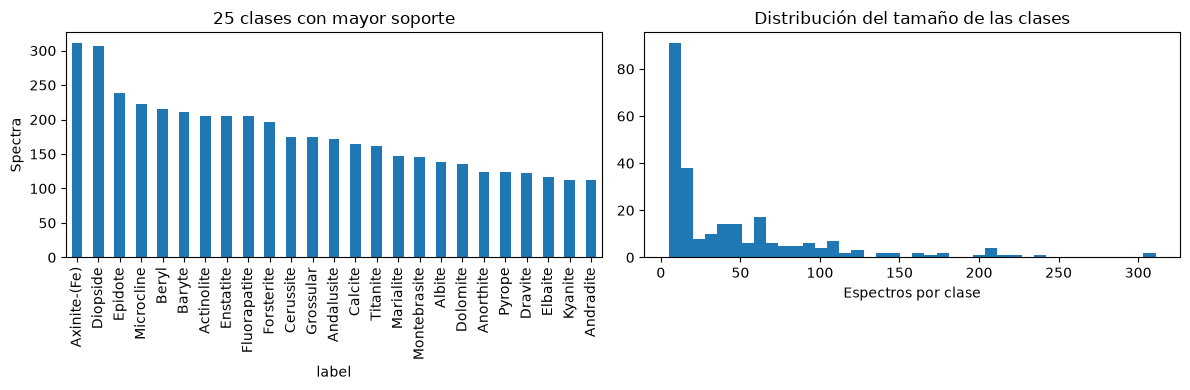

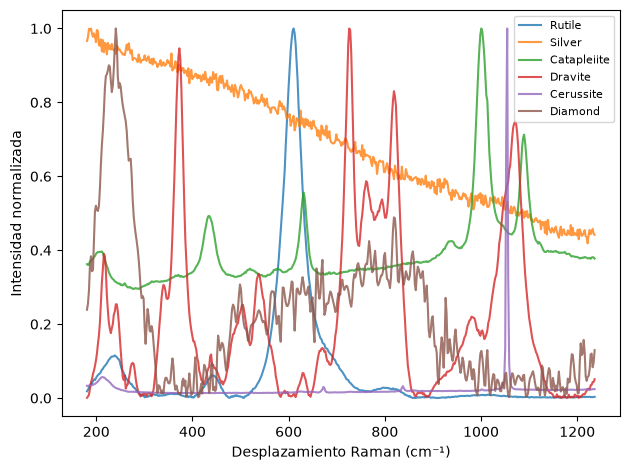

In [7]:
counts = metadata["label"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.head(25).plot.bar(ax=axes[0]); axes[0].set_title("25 clases con mayor soporte"); axes[0].set_ylabel("Spectra")
axes[1].hist(counts.values, bins=40); axes[1].set_title("Distribución del tamaño de las clases"); axes[1].set_xlabel("Espectros por clase")
plt.tight_layout(); plt.show()

rng = np.random.default_rng(SEED)
for idx in rng.choice(len(X), size=min(6, len(X)), replace=False):
    plt.plot(target_grid, X[idx], alpha=0.8, label=metadata.loc[idx, "label"])
plt.xlabel("Desplazamiento Raman (cm⁻¹)"); plt.ylabel("Intensidad normalizada")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


## 8. Partición congelada por fuentes

Una fuente completa pertenece a train, validation o test, incluso si aparece en varios ZIP. Se buscan particiones candidatas solo para mejorar equilibrio y cobertura de dominios, nunca usando etiquetas predichas.

In [8]:
def candidate_global_source_split(metadata_subset, seed):
    """Reserva una fuente para validación y otra para prueba por clase; cada fuente se mantiene globalmente en una sola partición."""
    rng = np.random.default_rng(seed)
    source_partition = {}
    for label in sorted(metadata_subset["label"].unique()):
        sources = metadata_subset.loc[metadata_subset["label"] == label, "source_id"].drop_duplicates().to_numpy(dtype=object)
        if len(sources) < MIN_SOURCE_GROUPS:
            raise AssertionError(f"{label} has fewer than {MIN_SOURCE_GROUPS} grupos de fuentes globales")
        rng.shuffle(sources)
        source_partition[sources[0]] = "test"
        source_partition[sources[1]] = "validation"
        for source_id in sources[2:]:
            source_partition[source_id] = "train"
    partitions = metadata_subset["source_id"].map(source_partition)
    if partitions.isna().any():
        raise AssertionError("Al menos una fuente no fue asignada globalmente")
    return partitions

required_domains = set(metadata["dataset_subset"].unique())
if required_domains != {Path(name).stem for name in REQUIRED_ZIP_FILENAMES}:
    raise AssertionError("El conjunto mixto retenido no contiene los siete dominios requeridos")

def split_balance_score(partitions):
    table = pd.crosstab(partitions, metadata["dataset_subset"]).reindex(
        index=["train", "validation", "test"], columns=sorted(required_domains), fill_value=0
    )
    # La separación por fuentes es obligatoria; la cobertura completa de dominios es un objetivo de optimización.
    # Algunas combinaciones raras de fuente y dominio impiden completar las 21 celdas partición-dominio.
    missing_cells = int((table == 0).sum().sum())
    heldout_missing = int((table.loc[["validation", "test"]] == 0).sum().sum())
    train_missing = int((table.loc["train"] == 0).sum())
    # Se favorece una composición de dominios similar en validación y prueba, además de tamaños comparables.
    composition = table.div(table.sum(axis=1), axis=0)
    val_test_gap = float(np.square(composition.loc["validation"] - composition.loc["test"]).sum())
    heldout_size_gap = float(abs(table.loc["validation"].sum() - table.loc["test"].sum()) / len(metadata))
    # Lexicographic priorities encoded numerically: training coverage, held-out coverage, balance.
    score = 1000.0 * train_missing + 100.0 * heldout_missing + val_test_gap + heldout_size_gap
    return score, table, missing_cells, train_missing, heldout_missing

best = None
candidate_rows = []
for offset in range(N_SPLIT_CANDIDATES):
    candidate_seed = SEED + offset
    candidate = candidate_global_source_split(metadata, candidate_seed)
    score, domain_table, missing_cells, train_missing, heldout_missing = split_balance_score(candidate)
    candidate_rows.append({
        "seed": candidate_seed, "balance_score": score,
        "missing_partition_domain_cells": missing_cells,
        "missing_training_domains": train_missing,
        "missing_heldout_domain_cells": heldout_missing,
        "all_domains_in_each_partition": bool(missing_cells == 0),
    })
    if best is None or score < best[0]:
        best = (score, candidate_seed, candidate, domain_table, missing_cells)

pd.DataFrame(candidate_rows).to_csv(RESULTS_DIR / "split_candidate_search.csv", index=False)
if best is None:
    raise RuntimeError("La búsqueda de particiones candidatas no produjo ninguna partición")

best_score, selected_split_seed, partition_series, split_domain_table, missing_domain_cells = best
train_idx = metadata.index[partition_series == "train"].to_numpy(dtype=np.int64)
val_idx = metadata.index[partition_series == "validation"].to_numpy(dtype=np.int64)
test_idx = metadata.index[partition_series == "test"].to_numpy(dtype=np.int64)

partition_sources = {
    "train": set(metadata.loc[train_idx, "source_id"]),
    "validation": set(metadata.loc[val_idx, "source_id"]),
    "test": set(metadata.loc[test_idx, "source_id"]),
}
assert partition_sources["train"].isdisjoint(partition_sources["validation"])
assert partition_sources["train"].isdisjoint(partition_sources["test"])
assert partition_sources["validation"].isdisjoint(partition_sources["test"])
assert set(np.unique(y[train_idx])) == set(np.unique(y[val_idx])) == set(np.unique(y[test_idx])) == set(range(n_classes))

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

split_manifest = metadata.copy()
split_manifest["class_index"] = y
split_manifest["partition"] = partition_series.to_numpy()
split_manifest.to_csv(RESULTS_DIR / "GLOBAL_GROUP_AWARE_MIXED_DOMAIN_SPLIT_MANIFEST.csv", index=False)
split_manifest.to_csv(RESULTS_DIR / "FROZEN_SPLIT_MANIFEST.csv", index=False)

source_allocation = (split_manifest.groupby(["label", "source_id", "partition"], as_index=False)
                     .agg(n_spectra=("spectrum_id", "size"),
                          n_domains=("dataset_subset", "nunique"),
                          domains=("dataset_subset", lambda s: " | ".join(sorted(set(s))))))
source_allocation.to_csv(RESULTS_DIR / "GLOBAL_SOURCE_ALLOCATION.csv", index=False)

source_domain_allocation = (split_manifest.groupby(["partition", "dataset_subset"], as_index=False)
                            .agg(sources=("source_id", "nunique"), spectra=("spectrum_id", "size")))
source_domain_allocation.to_csv(RESULTS_DIR / "ALL_7_ZIPS_PARTITION_REPORT.csv", index=False)

domain_coverage = split_domain_table.copy()
domain_coverage.index.name = "partition"
domain_coverage = domain_coverage.reset_index().melt(
    id_vars="partition", var_name="dataset_subset", value_name="spectra"
)
domain_coverage["present"] = domain_coverage["spectra"] > 0
domain_coverage.to_csv(RESULTS_DIR / "DOMAIN_COVERAGE_FEASIBILITY_REPORT.csv", index=False)

overlap_audit = pd.DataFrame([
    {"partition_a": "train", "partition_b": "validation", "source_overlap": len(partition_sources["train"] & partition_sources["validation"])},
    {"partition_a": "train", "partition_b": "test", "source_overlap": len(partition_sources["train"] & partition_sources["test"])},
    {"partition_a": "validation", "partition_b": "test", "source_overlap": len(partition_sources["validation"] & partition_sources["test"])},
])
overlap_audit.to_csv(RESULTS_DIR / "SOURCE_OVERLAP_AUDIT.csv", index=False)
assert (overlap_audit["source_overlap"] == 0).all()

np.save(RESULTS_DIR / "train_indices.npy", train_idx)
np.save(RESULTS_DIR / "validation_indices.npy", val_idx)
np.save(RESULTS_DIR / "test_indices.npy", test_idx)

display(source_domain_allocation.pivot(index="dataset_subset", columns="partition", values=["sources", "spectra"]).fillna(0).astype(int))
display(overlap_audit)
print(f"Semilla seleccionada para la partición: {selected_split_seed}; puntuación de equilibrio: {best_score:.6f}")
print(f"Entrenamiento: {len(train_idx)} | Validación: {len(val_idx)} | Prueba: {len(test_idx)}")
print(f"Cobertura de dominios: {21 - missing_domain_cells}/21 combinaciones partición-dominio representadas")
if missing_domain_cells:
    missing = domain_coverage.loc[~domain_coverage["present"], ["partition", "dataset_subset"]]
    print("ADVERTENCIA: no es posible lograr cobertura completa de dominios en cada partición bajo la separación global por fuentes seleccionada.")
    display(missing.reset_index(drop=True))
print("✓ Partición mixta independiente por fuentes creada; los siete ZIP fueron auditados conjuntamente")



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/split_candidate_search.csv | dimensiones: (1000, 6)


,seed,balance_score,missing_partition_domain_cells,missing_training_domains,missing_heldout_domain_cells,all_domains_in_each_partition
0,42,100.020789,1,0,1,False
1,43,200.029789,2,0,2,False
2,44,200.017380,2,0,2,False
3,45,200.014306,2,0,2,False
4,46,200.026081,2,0,2,False
5,47,200.007210,2,0,2,False
6,48,200.013914,2,0,2,False
7,49,200.018853,2,0,2,False
8,50,200.006334,2,0,2,False
9,51,100.019808,1,0,1,False



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/GLOBAL_GROUP_AWARE_MIXED_DOMAIN_SPLIT_MANIFEST.csv | dimensiones: (11912, 9)


,spectrum_id,filepath,filename,dataset_subset,label,source_id,source_id_status,class_index,partition
0,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
1,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
2,S000010,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
3,S000011,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
4,S000012,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__785______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
5,S000013,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__785______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,validation
6,S000014,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
7,S000015,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
8,S000016,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
9,S000017,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/FROZEN_SPLIT_MANIFEST.csv | dimensiones: (11912, 9)


...

sources                  spectra                 
partition               test train validation    test train validation
dataset_subset                                                        
excellent_oriented        58   190         59     956  2892        954
excellent_unoriented     222   534        207     804  2019        771
fair_oriented              1     1          0       2     8          0
fair_unoriented           53   108         58     129   290        152
poor_unoriented           39    61         47      84   119        115
unrated_oriented          62   221         63     505  1587        485
unrated_unoriented         6     9          9       8    16         16

,partition_a,partition_b,source_overlap
0,train,validation,0
1,train,test,0
2,validation,test,0


Semilla seleccionada para la partición: 224; puntuación de equilibrio: 100.000933
Entrenamiento: 6931 | Validación: 2493 | Prueba: 2488
Cobertura de dominios: 20/21 combinaciones partición-dominio representadas
ADVERTENCIA: no es posible lograr cobertura completa de dominios en cada partición bajo la separación global por fuentes seleccionada.


,partition,dataset_subset
0,validation,fair_oriented


✓ Partición mixta independiente por fuentes creada; los siete ZIP fueron auditados conjuntamente


## 9. Pipeline end-to-end de Random Forest

El bosque trabaja directamente con las 512 intensidades armonizadas. No necesita escalado; el paso `scaler='passthrough'` hace explícito que el pipeline conserva la señal normalizada. Los pesos balanceados reducen el sesgo hacia clases frecuentes.

El grid es deliberadamente moderado: **24 combinaciones** × un único fold train→validation. Compara 10, 100 y 300 árboles, dos profundidades, dos estrategias de selección de variables y dos tamaños mínimos de hoja; cada bosque usa todos los núcleos disponibles. La métrica de selección es **macro F1**, adecuada porque concede el mismo peso a cada clase mineral.

In [9]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("scaler", "passthrough"),
    ("classifier", RandomForestClassifier(class_weight="balanced_subsample", random_state=SEED, n_jobs=-1)),
])

param_grid = {
    "classifier__n_estimators": [10, 100, 300],
    "classifier__max_depth": [None, 30],
    "classifier__max_features": ["sqrt", 0.25],
    "classifier__min_samples_leaf": [1, 2],
}

# PredefinedSplit codifica una sola comparación: entrenamiento para ajustar y validación para seleccionar.
X_search = np.concatenate([X_train, X_val], axis=0)
y_search = np.concatenate([y_train, y_val], axis=0)
fold = np.concatenate([np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)])
predefined_split = PredefinedSplit(fold)

search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=SCORING,
    cv=predefined_split,
    refit=False,
    n_jobs=1,
    return_train_score=True,
    verbose=2,
    error_score="raise",
)

start = time.perf_counter()
search.fit(X_search, y_search)
search_minutes = (time.perf_counter() - start) / 60

cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
cv_results.to_csv(RESULTS_DIR / "grid_search_results.csv", index=False)
best_params = search.best_params_
(RESULTS_DIR / "best_hyperparameters.json").write_text(json.dumps(best_params, indent=2), encoding="utf-8")

display(cv_results[["rank_test_score", "mean_test_score", "mean_train_score", "mean_fit_time", "params"]])
print("Mejores hiperparámetros:", best_params)
print(f"Macro F1 de validación: {search.best_score_:.4f}")
print(f"Tiempo del grid search: {search_minutes:.2f} minutos")


Fitting 1 folds for each of 24 candidates, totalling 24 fits
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__n_estimators=10; total time=  29.5s
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__n_estimators=100; total time= 6.3min
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__n_estimators=300; total time=12.4min
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__n_estimators=10; total time=  24.5s
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__n_estimators=100; total time= 3.4min
[CV] END classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__n_estimators=300; total time= 9.8min
[CV] END classifier__max_depth=None, classifier

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__max_depth,param_classifier__max_features,param_classifier__min_samples_leaf,param_classifier__n_estimators,params,split0_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,mean_train_score,std_train_score
5,586.651578,0.0,0.992761,0.0,None,sqrt,2,300,"{'classifier__max_depth': None, 'classifier__m...",0.383771,0.383771,0.0,1,0.981378,0.981378,0.0
1,380.221502,0.0,0.375608,0.0,None,sqrt,1,100,"{'classifier__max_depth': None, 'classifier__m...",0.376168,0.376168,0.0,2,1.000000,1.000000,0.0
4,206.426145,0.0,0.511387,0.0,None,sqrt,2,100,"{'classifier__max_depth': None, 'classifier__m...",0.374864,0.374864,0.0,3,0.981454,0.981454,0.0
2,741.526343,0.0,1.218233,0.0,None,sqrt,1,300,"{'classifier__max_depth': None, 'classifier__m...",0.374690,0.374690,0.0,4,1.000000,1.000000,0.0
3,24.498596,0.0,0.040227,0.0,None,sqrt,2,10,"{'classifier__max_depth': None, 'classifier__m...",0.360528,0.360528,0.0,5,0.956934,0.956934,0.0
10,982.150444,0.0,0.541662,0.0,None,0.25,2,100,"{'classifier__max_depth': None, 'classifier__m...",0.356246,0.356246,0.0,6,0.968516,0.968516,0.0
11,4382.512397,0.0,1.078813,0.0,None,0.25,2,300,"{'classifier__max_depth': None, 'classifier__m...",0.351766,0.351766,0.0,7,0.971149,0.971149,0.0
7,1109.709961,0.0,0.301362,0.0,None,0.25,1,100,"{'classifier__max_depth': None, 'classifier__m...",0.347066,0.347066,0.0,8,1.000000,1.000000,0.0
8,2257.570943,0.0,0.657068,0.0,None,0.25,1,300,"{'classifier__max_depth': None, 'classifier__m...",0.346225,0.346225,0.0,9,1.000000,1.000000,0.0
0,29.386714,0.0,0.064322,0.0,None,sqrt,1,10,"{'classifier__max_depth': None, 'classifier__m...",0.337127,0.337127,0.0,10,0.990035,0.990035,0.0


[SOLO PANTALLA] best_hyperparameters.json:
{
  "classifier__max_depth": null,
  "classifier__max_features": "sqrt",
  "classifier__min_samples_leaf": 2,
  "classifier__n_estimators": 300
}


,rank_test_score,mean_test_score,mean_train_score,mean_fit_time,params
5,1,0.383771,0.981378,586.651578,"{'classifier__max_depth': None, 'classifier__m..."
1,2,0.376168,1.000000,380.221502,"{'classifier__max_depth': None, 'classifier__m..."
4,3,0.374864,0.981454,206.426145,"{'classifier__max_depth': None, 'classifier__m..."
2,4,0.374690,1.000000,741.526343,"{'classifier__max_depth': None, 'classifier__m..."
3,5,0.360528,0.956934,24.498596,"{'classifier__max_depth': None, 'classifier__m..."
10,6,0.356246,0.968516,982.150444,"{'classifier__max_depth': None, 'classifier__m..."
11,7,0.351766,0.971149,4382.512397,"{'classifier__max_depth': None, 'classifier__m..."
7,8,0.347066,1.000000,1109.709961,"{'classifier__max_depth': None, 'classifier__m..."
8,9,0.346225,1.000000,2257.570943,"{'classifier__max_depth': None, 'classifier__m..."
0,10,0.337127,0.990035,29.386714,"{'classifier__max_depth': None, 'classifier__m..."


Mejores hiperparámetros: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 300}
Macro F1 de validación: 0.3838
Tiempo del grid search: 217.01 minutos


## 10. Funciones de evaluación multiclase

Se calculan las mismas métricas diagnósticas principales de los notebooks CNN. AUROC y AUPRC son complementarias y solo se calculan para clases evaluables.

In [10]:
def probabilidades_del_estimador(estimator, X_input):
    """Devuelve probabilidades alineadas con todas las clases del codificador."""
    if hasattr(estimator, "predict_proba"):
        raw = estimator.predict_proba(X_input)
    elif hasattr(estimator, "decision_function"):
        raw = softmax(estimator.decision_function(X_input), axis=1)
    else:
        raise TypeError("El estimador no ofrece predict_proba ni decision_function.")
    raw = np.asarray(raw, dtype=np.float64)
    classes_seen = np.asarray(estimator.classes_, dtype=int)
    aligned = np.zeros((len(X_input), n_classes), dtype=np.float64)
    aligned[:, classes_seen] = raw
    aligned = np.clip(aligned, 1e-12, 1.0)
    aligned /= aligned.sum(axis=1, keepdims=True)
    return aligned

def expected_calibration_error(y_true, prob, bins=15):
    confidence = prob.max(axis=1)
    correct = (prob.argmax(axis=1) == y_true).astype(float)
    edges = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (confidence > lo) & (confidence <= hi)
        if mask.any():
            ece += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
    return float(ece)

def metricas_multiclase(y_true, prob):
    pred = prob.argmax(axis=1)
    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        y_true, pred, average="macro", zero_division=0
    )
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, pred, average="weighted", zero_division=0
    )
    present = np.unique(y_true)
    y_bin = label_binarize(y_true, classes=np.arange(n_classes))
    evaluable = [c for c in present if 0 < y_bin[:, c].sum() < len(y_true)]
    auroc_macro = auroc_weighted = auprc_macro = auprc_weighted = np.nan
    if evaluable:
        yt, yp = y_bin[:, evaluable], prob[:, evaluable]
        auroc_macro = roc_auc_score(yt, yp, average="macro")
        auroc_weighted = roc_auc_score(yt, yp, average="weighted")
        auprc_macro = average_precision_score(yt, yp, average="macro")
        auprc_weighted = average_precision_score(yt, yp, average="weighted")
    return {
        "cross_entropy": log_loss(y_true, prob, labels=np.arange(n_classes)),
        "top_1_accuracy": accuracy_score(y_true, pred),
        "top_3_accuracy": top_k_accuracy_score(y_true, prob, k=min(3, n_classes), labels=np.arange(n_classes)),
        "top_5_accuracy": top_k_accuracy_score(y_true, prob, k=min(5, n_classes), labels=np.arange(n_classes)),
        "macro_precision": precision_m, "macro_recall": recall_m, "macro_f1": f1_m,
        "weighted_precision": precision_w, "weighted_recall": recall_w, "weighted_f1": f1_w,
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "matthews_correlation_coefficient": matthews_corrcoef(y_true, pred),
        "auroc_macro_ovr": auroc_macro, "auroc_weighted_ovr": auroc_weighted,
        "auprc_macro_ovr": auprc_macro, "auprc_weighted_ovr": auprc_weighted,
        "multiclass_brier": float(np.mean(np.sum((prob - y_bin) ** 2, axis=1))),
        "expected_calibration_error": expected_calibration_error(y_true, prob),
        "evaluable_classes_roc_pr": len(evaluable),
    }


## 11. Reajuste del ganador y evaluación única sobre test

Después de congelar hiperparámetros, el pipeline se reajusta con train+validation. Test no decide ninguna configuración.

In [11]:
# La selección ya terminó. Se reconstruye el pipeline y se reajusta con train+validation.
final_pipeline = pipeline.set_params(**best_params)
start = time.perf_counter()
final_pipeline.fit(X_search, y_search)
refit_minutes = (time.perf_counter() - start) / 60

test_prob = probabilidades_del_estimador(final_pipeline, X_test)
test_pred = test_prob.argmax(axis=1)
test_metrics = metricas_multiclase(y_test, test_prob)
pd.DataFrame([test_metrics]).to_csv(RESULTS_DIR / "test_metrics.csv", index=False)
display(pd.DataFrame([test_metrics]).T.rename(columns={0: "valor"}))
print(f"Tiempo de reajuste final: {refit_minutes:.2f} minutos")
print("✓ Test se utilizó una sola vez, después de elegir los hiperparámetros")



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/test_metrics.csv | dimensiones: (1, 19)


,cross_entropy,top_1_accuracy,top_3_accuracy,top_5_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,balanced_accuracy,matthews_correlation_coefficient,auroc_macro_ovr,auroc_weighted_ovr,auprc_macro_ovr,auprc_weighted_ovr,multiclass_brier,expected_calibration_error,evaluable_classes_roc_pr
0,2.327946,0.678055,0.82918,0.869373,0.561322,0.562912,0.518867,0.739042,0.678055,0.671723,0.562912,0.675566,0.968475,0.981743,0.645039,0.786778,0.472482,0.143037,255


,valor
cross_entropy,2.327946
top_1_accuracy,0.678055
top_3_accuracy,0.829180
top_5_accuracy,0.869373
macro_precision,0.561322
macro_recall,0.562912
macro_f1,0.518867
weighted_precision,0.739042
weighted_recall,0.678055
weighted_f1,0.671723


Tiempo de reajuste final: 4.12 minutos
✓ Test se utilizó una sola vez, después de elegir los hiperparámetros


## 12. Matriz de confusión, errores por clase y análisis por dominio

La matriz completa se exporta para el anexo. Los pares de confusión y las métricas por ZIP facilitan una interpretación más legible ante el jurado.


[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/classification_report_255_classes.csv | dimensiones: (258, 4)


,precision,recall,f1-score,support
Actinolite,0.787234,0.973684,0.870588,38.0
Adamite,0.235294,1.000000,0.380952,4.0
Aegirine,0.000000,0.000000,0.000000,4.0
Agardite-(Y),1.000000,0.500000,0.666667,2.0
Albite,0.000000,0.000000,0.000000,3.0
Alluaudite,1.000000,0.500000,0.666667,4.0
Almandine,0.666667,1.000000,0.800000,4.0
Alum-(K),0.666667,0.666667,0.666667,6.0
Andalusite,0.933333,1.000000,0.965517,28.0
Andradite,0.923077,1.000000,0.960000,12.0



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/confusion_matrix_absolute.csv | dimensiones: (255, 255)


,Actinolite,Adamite,Aegirine,Agardite-(Y),Albite,Alluaudite,Almandine,Alum-(K),Andalusite,Andradite,...,Wendwilsonite,Whewellite,Willemite,Witherite,Wolfeite,Wollastonite,Wulfenite,Xenotime-(Y),Zincite,Zircon
Actinolite,37,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Adamite,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aegirine,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Agardite-(Y),0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Albite,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alluaudite,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Almandine,0,0,0,0,0,0,4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alum-(K),0,0,0,0,0,0,0,4,0,0,...,0,0,0,0,0,0,0,0,0,0
Andalusite,0,0,0,0,0,0,0,0,28,0,...,0,0,0,0,0,0,0,0,0,0
Andradite,0,0,0,0,0,0,0,0,0,12,...,0,0,0,0,0,0,0,0,0,0



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/confusion_matrix_normalized.csv | dimensiones: (255, 255)


,Actinolite,Adamite,Aegirine,Agardite-(Y),Albite,Alluaudite,Almandine,Alum-(K),Andalusite,Andradite,...,Wendwilsonite,Whewellite,Willemite,Witherite,Wolfeite,Wollastonite,Wulfenite,Xenotime-(Y),Zincite,Zircon
Actinolite,0.973684,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Adamite,0.000000,1.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Aegirine,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Agardite-(Y),0.000000,0.0,0.000000,0.5,0.0,0.0,0.0,0.000000,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Albite,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Alluaudite,0.000000,0.0,0.000000,0.0,0.0,0.5,0.0,0.000000,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Almandine,0.000000,0.0,0.000000,0.0,0.0,0.0,1.0,0.000000,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Alum-(K),0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.666667,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Andalusite,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,1.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Andradite,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,1.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


[SOLO PANTALLA] Figura mostrada; no se guarda raman_all_7_zips_random_forest_grid_search/results/confusion_matrix_normalized.png


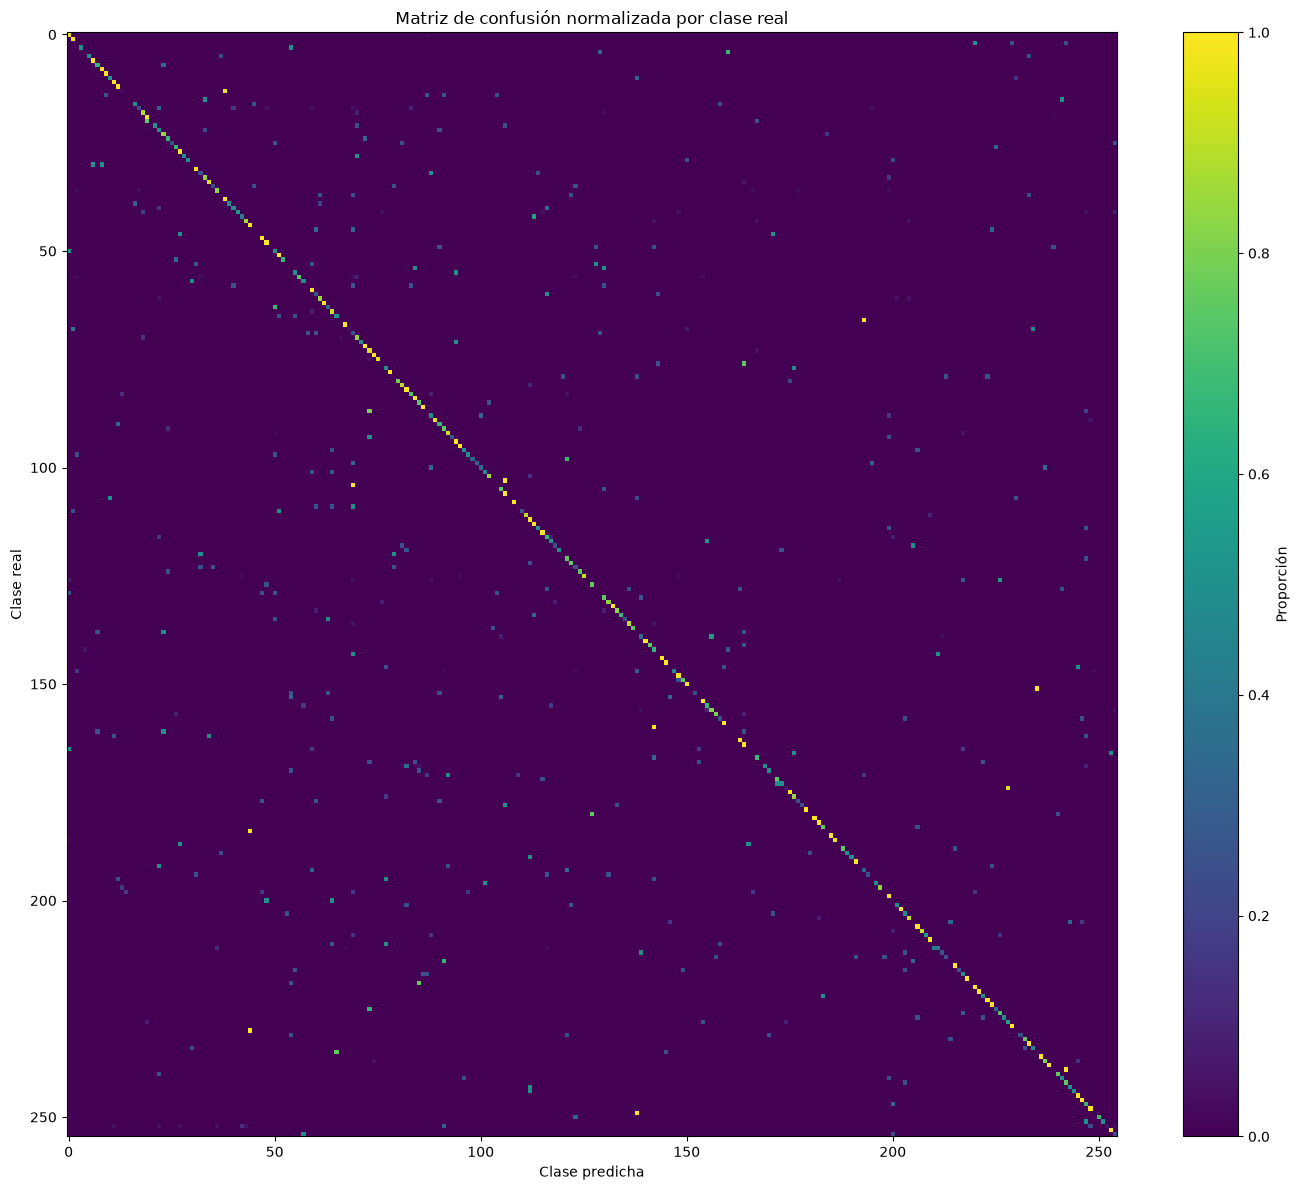


[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/most_frequent_confusions.csv | dimensiones: (404, 3)


,clase_real,clase_predicha,n
290,Polylithionite,Trilithionite,34
12,Aragonite,Calcite,29
37,Baryte,Retgersite,19
74,Cerussite,Hydrocerussite,16
118,Descloizite,Tyrolite,15
202,Leucophanite,Tremolite,15
227,Mesolite,Natrolite,14
348,Stibnite,Stephanite,14
232,Microcline,Orthoclase,14
116,Descloizite,Adamite,12


,clase_real,clase_predicha,n
290,Polylithionite,Trilithionite,34
12,Aragonite,Calcite,29
37,Baryte,Retgersite,19
74,Cerussite,Hydrocerussite,16
118,Descloizite,Tyrolite,15
202,Leucophanite,Tremolite,15
227,Mesolite,Natrolite,14
348,Stibnite,Stephanite,14
232,Microcline,Orthoclase,14
116,Descloizite,Adamite,12



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/test_predictions.csv | dimensiones: (2488, 13)


,spectrum_id,filepath,filename,dataset_subset,label,source_id,source_id_status,class_index,partition,true_label,predicted_label,confidence,correct
0,S000024,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite__R050336__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R050336,filename_header_agree,0,test,Actinolite,Actinolite,0.586341,True
1,S000025,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite__R050336__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R050336,filename_header_agree,0,test,Actinolite,Actinolite,0.476390,True
2,S000026,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite__R050336__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R050336,filename_header_agree,0,test,Actinolite,Actinolite,0.643653,True
3,S000027,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite__R050336__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R050336,filename_header_agree,0,test,Actinolite,Actinolite,0.367763,True
4,S000028,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite__R050336__Raman__780______Raman_Dat...,excellent_unoriented,Actinolite,R050336,filename_header_agree,0,test,Actinolite,Actinolite,0.403547,True
5,S000029,excellent_unoriented.zip::Actinolite__R050336_...,Actinolite__R050336__Raman__780______Raman_Dat...,excellent_unoriented,Actinolite,R050336,filename_header_agree,0,test,Actinolite,Fluor-uvite,0.093340,False
6,S000056,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite__R060593__Raman__532______Raman_Data_P...,excellent_unoriented,Adamite,R060593,filename_header_agree,1,test,Adamite,Adamite,0.458734,True
7,S000057,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite__R060593__Raman__532______Raman_Data_R...,excellent_unoriented,Adamite,R060593,filename_header_agree,1,test,Adamite,Adamite,0.518239,True
8,S000058,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite__R060593__Raman__780______Raman_Data_P...,excellent_unoriented,Adamite,R060593,filename_header_agree,1,test,Adamite,Adamite,0.732046,True
9,S000059,excellent_unoriented.zip::Adamite__R060593__Ra...,Adamite__R060593__Raman__780______Raman_Data_R...,excellent_unoriented,Adamite,R060593,filename_header_agree,1,test,Adamite,Adamite,0.756476,True


/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



[SOLO PANTALLA] raman_all_7_zips_random_forest_grid_search/results/test_metrics_by_domain.csv | dimensiones: (7, 21)


/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("

,domain,n_spectra,cross_entropy,top_1_accuracy,top_3_accuracy,top_5_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,...,weighted_f1,balanced_accuracy,matthews_correlation_coefficient,auroc_macro_ovr,auroc_weighted_ovr,auprc_macro_ovr,auprc_weighted_ovr,multiclass_brier,expected_calibration_error,evaluable_classes_roc_pr
0,excellent_oriented,956,1.685196,0.758368,0.893305,0.928870,0.553910,0.503659,0.506437,0.873963,...,0.789167,0.755489,0.753646,0.986544,0.991097,0.889480,0.910280,0.383646,0.153846,58
1,excellent_unoriented,804,2.447765,0.624378,0.815920,0.855721,0.557811,0.564870,0.527426,0.628072,...,0.590196,0.597948,0.623109,0.971351,0.974772,0.735871,0.756621,0.528615,0.124477,222
2,fair_oriented,2,1.208897,0.500000,1.000000,1.000000,0.500000,0.250000,0.333333,1.000000,...,0.666667,0.500000,0.000000,NaN,NaN,NaN,NaN,0.439782,0.106789,0
3,fair_unoriented,129,5.253357,0.379845,0.565891,0.627907,0.286738,0.209677,0.232104,0.532300,...,0.425914,0.367925,0.374351,0.888673,0.909762,0.606666,0.627036,0.820839,0.156696,53
4,poor_unoriented,84,5.932434,0.238095,0.452381,0.511905,0.171233,0.143836,0.145662,0.315476,...,0.250794,0.269231,0.233931,0.882871,0.869473,0.544789,0.522812,0.886895,0.126298,39
5,unrated_oriented,505,2.025185,0.762376,0.859406,0.900990,0.559313,0.508285,0.521405,0.858612,...,0.791882,0.770626,0.759660,0.990656,0.991039,0.902069,0.915449,0.393330,0.179170,62
6,unrated_unoriented,8,1.466817,0.625000,0.750000,0.750000,0.444444,0.388889,0.407407,0.750000,...,0.666667,0.583333,0.603881,0.976190,0.982143,0.916667,0.937500,0.482915,0.256871,6


,domain,n_spectra,top_1_accuracy,macro_f1,weighted_f1
0,excellent_oriented,956,0.758368,0.506437,0.789167
1,excellent_unoriented,804,0.624378,0.527426,0.590196
2,fair_oriented,2,0.500000,0.333333,0.666667
3,fair_unoriented,129,0.379845,0.232104,0.425914
4,poor_unoriented,84,0.238095,0.145662,0.250794
5,unrated_oriented,505,0.762376,0.521405,0.791882
6,unrated_unoriented,8,0.625000,0.407407,0.666667


In [12]:
report = classification_report(
    y_test, test_pred, labels=np.arange(n_classes), target_names=class_names,
    output_dict=True, zero_division=0
)
class_report = pd.DataFrame(report).T
class_report.to_csv(RESULTS_DIR / "classification_report_255_classes.csv")

cm = confusion_matrix(y_test, test_pred, labels=np.arange(n_classes))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sum, out=np.zeros_like(cm, dtype=float), where=row_sum != 0)
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(RESULTS_DIR / "confusion_matrix_absolute.csv")
pd.DataFrame(cm_norm, index=class_names, columns=class_names).to_csv(RESULTS_DIR / "confusion_matrix_normalized.csv")

plt.figure(figsize=(14, 12))
plt.imshow(cm_norm, cmap="viridis", aspect="auto", vmin=0, vmax=1)
plt.title("Matriz de confusión normalizada por clase real")
plt.xlabel("Clase predicha"); plt.ylabel("Clase real"); plt.colorbar(label="Proporción")
plt.tight_layout(); plt.savefig(RESULTS_DIR / "confusion_matrix_normalized.png", dpi=180); plt.show()

confusions = []
for true_i in range(n_classes):
    for pred_i in range(n_classes):
        if true_i != pred_i and cm[true_i, pred_i] > 0:
            confusions.append({"clase_real": class_names[true_i], "clase_predicha": class_names[pred_i], "n": int(cm[true_i, pred_i])})
confusion_pairs = pd.DataFrame(confusions).sort_values("n", ascending=False) if confusions else pd.DataFrame(columns=["clase_real", "clase_predicha", "n"])
confusion_pairs.to_csv(RESULTS_DIR / "most_frequent_confusions.csv", index=False)
display(confusion_pairs.head(30))

test_details = split_manifest.iloc[test_idx].reset_index(drop=True).copy()
test_details["true_label"] = encoder.inverse_transform(y_test)
test_details["predicted_label"] = encoder.inverse_transform(test_pred)
test_details["confidence"] = test_prob.max(axis=1)
test_details["correct"] = test_pred == y_test
test_details.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)

domain_rows = []
for domain in sorted(test_details["dataset_subset"].unique()):
    mask = test_details["dataset_subset"].to_numpy() == domain
    domain_rows.append({"domain": domain, "n_spectra": int(mask.sum()), **metricas_multiclase(y_test[mask], test_prob[mask])})
domain_metrics = pd.DataFrame(domain_rows)
domain_metrics.to_csv(RESULTS_DIR / "test_metrics_by_domain.csv", index=False)
display(domain_metrics[["domain", "n_spectra", "top_1_accuracy", "macro_f1", "weighted_f1"]])


## 13. Exportación del pipeline de producción

El archivo `joblib` contiene conjuntamente el preprocesamiento estadístico y el clasificador. Aun así, la interpolación a la rejilla Raman y la normalización física previa quedan documentadas en el contrato.

In [13]:
contract = {
    "modelo": MODEL_NAME, "mejores_hiperparametros": best_params,
    "validacion_macro_f1": float(search.best_score_), "test_metrics": test_metrics,
    "n_classes": int(n_classes), "split_seed": int(selected_split_seed),
}
check = probabilidades_del_estimador(final_pipeline, X_test[:min(8, len(X_test))])
assert check.shape[1] == n_classes and np.isfinite(check).all()
display(pd.DataFrame([contract]).T.rename(columns={0: "valor"}))
print("✓ Pipeline final verificado en memoria. No se guardaron archivos.")


,valor
modelo,Random Forest
mejores_hiperparametros,"{'classifier__max_depth': None, 'classifier__m..."
validacion_macro_f1,0.383771
test_metrics,"{'cross_entropy': 2.3279456018315257, 'top_1_a..."
n_classes,255
split_seed,224


✓ Pipeline final verificado en memoria. No se guardaron archivos.


## 14. Interpretación y limitaciones

- El resultado estima generalización a **fuentes RRUFF no vistas**.
- Un modelo clásico puede mostrar menor rendimiento que una CNN y seguir siendo valioso como baseline interpretable y computacionalmente distinto.
- El grid reducido limita el coste y el riesgo de sobreajuste a validación, pero no garantiza el óptimo global.
- La comparación defendible con las CNN debe mantener el mismo manifiesto de split y reportar tanto rendimiento como tiempo, memoria y complejidad del despliegue.